
# Triadic Cell Notebook v16
## Outcome as readout, not objective

This notebook takes the correction seriously:

- do **not** force zero
- do **not** optimize directly on residual
- let the search law run
- treat outcome metrics as witnesses

So the runtime is now driven by a **search-law objective**, not a zero objective.

## Core principle

Wrong:
$$
\min \Omega
$$

Better:
$$
\min \left(
\text{contradiction}
+
\text{ambiguity}
+
\text{trust instability}
+
\text{rewrite error}
\right)
$$

Then we only **observe**:
- residual $\Omega$
- STI
- zero-band entry

Those are outputs, not steering variables.



## Search-law terms used here

We use four internal pressures:

1. **contradiction**
   - recalled pattern disagrees with target pattern

2. **ambiguity**
   - top two slot scores are too close

3. **trust instability**
   - trust state changes too violently

4. **rewrite error**
   - writing to one slot disturbs other slots too much

The runtime tries to reduce those by:
- strengthening template anchoring when contradiction persists
- cooling ambiguous branches
- damping rapid trust swings
- suppressing updates that create broad spill

Outcome metrics are logged after the fact.


In [1]:

from __future__ import annotations

from dataclasses import dataclass
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

rng = np.random.default_rng(42)

print("Environment ready.")


Environment ready.


In [2]:

@dataclass
class AddressedTriadicState:
    coherence: float = 0.72
    latent: np.ndarray = None
    readout: np.ndarray = None

    def __post_init__(self):
        if self.latent is None:
            self.latent = np.array([0.20, 0.35, 0.50, 0.15], dtype=float)
        if self.readout is None:
            self.readout = np.zeros(2, dtype=float)

    def copy(self):
        return AddressedTriadicState(
            coherence=float(self.coherence),
            latent=self.latent.copy(),
            readout=self.readout.copy(),
        )


@dataclass
class CalibrationState:
    trust: float = 0.50
    error_ledger: np.ndarray = None
    omega_history: list = None
    search_history: list = None

    def __post_init__(self):
        if self.error_ledger is None:
            self.error_ledger = np.zeros(4, dtype=float)
        if self.omega_history is None:
            self.omega_history = []
        if self.search_history is None:
            self.search_history = []

    def copy(self):
        return CalibrationState(
            trust=float(self.trust),
            error_ledger=self.error_ledger.copy(),
            omega_history=list(self.omega_history),
            search_history=list(self.search_history),
        )


In [3]:

class KeyedMemoryBank:
    def __init__(self, width: int = 4, leak: float = 0.015):
        self.width = width
        self.leak = float(leak)

        self.keys = np.array([
            [1.0, 0.2, 0.0, 0.0],
            [0.0, 1.0, 0.2, 0.0],
            [0.2, 0.0, 1.0, 0.2],
            [0.0, 0.2, 0.0, 1.0],
        ], dtype=float)
        self.keys = self.keys / np.linalg.norm(self.keys, axis=1, keepdims=True)
        self.slots = np.zeros((4, width), dtype=float)

    @staticmethod
    def _softmax(x: np.ndarray, temp: float = 1.0) -> np.ndarray:
        z = (x - np.max(x)) / max(temp, 1e-8)
        e = np.exp(z)
        return e / np.sum(e)

    def address(self, query: np.ndarray, content_mix: float = 0.15) -> np.ndarray:
        q = query / (np.linalg.norm(query) + 1e-8)
        key_scores = self.keys @ q

        if np.any(self.slots > 0):
            slot_norms = np.linalg.norm(self.slots, axis=1, keepdims=True) + 1e-8
            slot_dirs = self.slots / slot_norms
            content_scores = slot_dirs @ q
        else:
            content_scores = np.zeros_like(key_scores)

        scores = (1.0 - content_mix) * key_scores + content_mix * content_scores
        return self._softmax(scores, temp=0.08)

    def read(self, weights: np.ndarray) -> np.ndarray:
        return weights @ self.slots

    def write(self, weights: np.ndarray, value: np.ndarray, strength: float, topk: int = 1):
        before = self.slots.copy()
        self.slots *= (1.0 - self.leak)

        idx = np.argsort(weights)[::-1][:topk]
        masked = np.zeros_like(weights)
        masked[idx] = weights[idx]
        if masked.sum() > 0:
            masked = masked / masked.sum()

        for i in range(self.slots.shape[0]):
            self.slots[i] = np.clip(self.slots[i] + strength * masked[i] * value, 0.0, 1.0)

        delta = self.slots - before
        return masked.copy(), delta

    def slot_energy(self) -> np.ndarray:
        return self.slots.mean(axis=1)

    def copy(self):
        return copy.deepcopy(self)


In [4]:

def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    na = np.linalg.norm(a) + 1e-8
    nb = np.linalg.norm(b) + 1e-8
    return float(np.dot(a, b) / (na * nb))

def nearest_index_and_margin(vec: np.ndarray, library: np.ndarray):
    sims = np.array([cosine_similarity(vec, p) for p in library], dtype=float)
    order = np.argsort(sims)[::-1]
    best = int(order[0])
    top1 = float(sims[order[0]])
    top2 = float(sims[order[1]]) if len(order) > 1 else 0.0
    return best, top1, top1 - top2


In [5]:

class TriadicCellV16:
    def __init__(self, B: float = 1.0, T: float = 1.0, R: float = 1.0):
        self.B = float(B)
        self.T = float(T)
        self.R = float(R)

        self.W_readout = np.array([
            [1.0, 0.2, 0.0, -0.3],
            [0.0, 0.8, -0.4, 0.6],
        ], dtype=float)

        self.W_query = np.array([
            [1.0, 0.0, 0.3, 0.0],
            [0.0, 1.0, 0.0, 0.4],
            [0.3, 0.0, 1.0, 0.0],
            [0.0, 0.4, 0.0, 1.0],
        ], dtype=float)

    @staticmethod
    def _clip(x):
        return np.clip(x, 0.0, 1.0)

    def _query(self, latent: np.ndarray) -> np.ndarray:
        raw_query = self.W_query @ latent
        return raw_query / (np.linalg.norm(raw_query) + 1e-8)

    def probe(self, cue: np.ndarray, bank: KeyedMemoryBank):
        query = self._query(cue)
        addr = bank.address(query, content_mix=0.15)
        recalled = bank.read(addr)
        return addr.copy(), recalled.copy()

    def step(
        self,
        s: AddressedTriadicState,
        drive_vec: np.ndarray,
        bank: KeyedMemoryBank,
        cal: CalibrationState,
        target_slot: int | None = None,
        template_pull: float = 0.35,
        templates: np.ndarray | None = None,
        novelty_threshold: float = 0.10,
    ):
        query = self._query(s.latent)
        addr = bank.address(query, content_mix=0.15)
        recalled = bank.read(addr)

        load = np.linalg.norm(s.readout) + 0.2 * np.linalg.norm(recalled)
        coherence_restore = 0.05 * self.B * (0.84 - s.coherence)
        coherence_burn = 0.07 * self.T * (1.0 - self.B) + 0.008 * load
        coherence = float(np.clip(s.coherence + coherence_restore - coherence_burn, 0.0, 1.0))

        composite_target = 0.72 * drive_vec + 0.28 * recalled
        follow = 0.20 * self.B * self.T * coherence * (composite_target - s.latent)
        static_drag = 0.04 * (1.0 - self.T) * (s.latent - np.array([0.20, 0.35, 0.50, 0.15]))
        unsupported_loss = 0.14 * self.T * (1.0 - self.B) * s.latent
        latent = self._clip(s.latent + follow - static_drag - unsupported_loss)

        delta_vec = np.abs(latent - s.latent)
        support = self.B * self.T * self.R * coherence
        projected = self.W_readout @ delta_vec
        projected = np.maximum(projected, 0.0)

        shell_decay = (0.18 * (1.0 - self.T) + 0.12 * (1.0 - self.R)) * s.readout
        readout = self._clip(0.82 * s.readout + 2.25 * support * projected - shell_decay)

        corrective_boost = 0.0
        if target_slot is not None:
            corrective_boost = float(cal.error_ledger[target_slot])

        # search-law adaptation: stronger correction only when contradiction persists
        base_write_strength = float((0.55 + 0.25 * corrective_boost) * support * readout.mean())
        novelty = max(0.0, 1.0 - cosine_similarity(recalled, drive_vec) - novelty_threshold)
        write_strength = base_write_strength * novelty

        if target_slot is not None:
            weights = np.zeros(4, dtype=float)
            weights[target_slot] = 1.0
        else:
            weights = addr

        write_value = latent.copy()
        if target_slot is not None and templates is not None and template_pull > 0.0:
            local_pull = min(0.80, template_pull + 0.20 * corrective_boost)
            write_value = np.clip((1.0 - local_pull) * latent + local_pull * templates[target_slot], 0.0, 1.0)

        masked, delta = bank.write(weights, write_value, write_strength, topk=1 if target_slot is not None else 2)

        next_state = AddressedTriadicState(
            coherence=coherence,
            latent=latent,
            readout=readout,
        )
        return next_state, delta



## Patterns and cues


In [6]:

patterns = np.array([
    [1.00, 0.05, 0.05, 0.05],
    [0.05, 1.00, 0.05, 0.05],
    [0.05, 0.05, 1.00, 0.05],
    [0.05, 0.05, 0.05, 1.00],
], dtype=float)

def partial_cue(pattern: np.ndarray, mask_prob: float = 0.5, noise: float = 0.04) -> np.ndarray:
    cue = pattern.copy()
    mask = rng.random(pattern.shape[0]) < mask_prob
    cue[mask] = 0.0
    cue += rng.normal(0.0, noise, size=cue.shape[0])
    return np.clip(cue, 0.0, 1.0)



## Persistence modes

We keep the most informative carriers from v15.


In [7]:

def apply_persistence_mode(mode: str, state: AddressedTriadicState, bank: KeyedMemoryBank, cal: CalibrationState):
    if mode == "bank + latent":
        s = AddressedTriadicState()
        s.latent = state.latent.copy()
        return s, bank.copy(), CalibrationState()

    if mode == "bank + latent + trust":
        s = AddressedTriadicState()
        s.latent = state.latent.copy()
        c = CalibrationState(trust=float(cal.trust))
        return s, bank.copy(), c

    if mode == "bank + latent + trust + ledger":
        s = AddressedTriadicState()
        s.latent = state.latent.copy()
        return s, bank.copy(), cal.copy()

    if mode == "full + trust + ledger":
        return state.copy(), bank.copy(), cal.copy()

    raise ValueError(f"Unknown mode: {mode}")



## Search episode

We do not optimize residual directly.

Instead each recall computes:

- contradiction = residual
- ambiguity = 1 - margin
- trust instability = |trust_t - trust_{t-1}|
- rewrite error = off-target update spill

Then we update the calibration channels from those terms.


In [8]:

def run_episode(
    model: TriadicCellV16,
    state: AddressedTriadicState,
    bank: KeyedMemoryBank,
    cal: CalibrationState,
    zero_floor: float = 0.05,
):
    # storage phase
    rewrite_spill_terms = []

    for slot_idx, p in enumerate(patterns):
        for _ in range(10):
            drive = np.clip(p + rng.normal(0.0, 0.03, size=p.shape[0]), 0.0, 1.0)
            state, delta = model.step(
                state,
                drive,
                bank,
                cal,
                target_slot=slot_idx,
                template_pull=0.35,
                templates=patterns,
                novelty_threshold=0.10,
            )

            # spill outside target slot
            slot_delta = np.mean(np.abs(delta), axis=1)
            target_change = slot_delta[slot_idx]
            collateral = np.mean(np.delete(slot_delta, slot_idx))
            rewrite_spill = collateral / (target_change + 1e-8)
            rewrite_spill_terms.append(rewrite_spill)

    # probe phase
    rows = []
    bank_templates = bank.slots.copy()
    prev_trust = float(cal.trust)

    for idx, p in enumerate(patterns):
        slot_errors = []
        for _ in range(16):
            cue = partial_cue(p, mask_prob=0.5, noise=0.04)
            addr, recalled = model.probe(cue, bank)

            pred_bank, _, bank_margin = nearest_index_and_margin(recalled, bank_templates)
            omega = 1.0 - cosine_similarity(recalled, p)
            ambiguity = 1.0 - np.clip(bank_margin, 0.0, 1.0)

            # passive trust evolution from search-law pressure
            contradiction = omega
            instability = abs(cal.trust - prev_trust)
            rewrite_error = float(np.mean(rewrite_spill_terms)) if rewrite_spill_terms else 0.0

            search_pressure = (
                0.45 * contradiction +
                0.30 * ambiguity +
                0.15 * instability +
                0.10 * rewrite_error
            )

            # trust update is derived from search pressure, not omega target
            proposed_trust = 1.0 - np.clip(search_pressure, 0.0, 1.0)
            cal.trust = 0.90 * cal.trust + 0.10 * proposed_trust
            prev_trust = float(cal.trust)

            accepted = (bank_margin > 0.02) and (cal.trust > 0.58)

            rows.append({
                "target_slot": idx,
                "pred_bank": pred_bank,
                "omega": omega,
                "ambiguity": ambiguity,
                "bank_margin": bank_margin,
                "accepted": accepted,
                "zero_hit": omega < zero_floor,
                "trust": float(cal.trust),
                "search_pressure": float(search_pressure),
                "rewrite_error": rewrite_error,
            })

            slot_errors.append(omega)
            cal.omega_history.append(omega)
            cal.search_history.append(search_pressure)

        # update ledger from contradiction, not from zero target
        slot_mean_omega = float(np.mean(slot_errors))
        cal.error_ledger[idx] = 0.85 * cal.error_ledger[idx] + 0.15 * slot_mean_omega

    probe_df = pd.DataFrame(rows)
    return state, bank, cal, probe_df


In [9]:

def summarize_episode(probe_df: pd.DataFrame, bank: KeyedMemoryBank, cal: CalibrationState):
    bank_acc = float((probe_df["pred_bank"] == probe_df["target_slot"]).mean())

    accepted = probe_df[probe_df["accepted"]].copy()
    coverage = len(accepted) / len(probe_df)
    accepted_acc = float((accepted["pred_bank"] == accepted["target_slot"]).mean()) if len(accepted) else np.nan

    mean_omega = float(probe_df["omega"].mean())
    sti = 1.0 - mean_omega

    return {
        "bank_accuracy": bank_acc,
        "coverage": coverage,
        "accepted_accuracy": accepted_acc,
        "mean_omega": mean_omega,
        "sti": sti,
        "mean_margin": float(probe_df["bank_margin"].mean()),
        "mean_ambiguity": float(probe_df["ambiguity"].mean()),
        "mean_search_pressure": float(probe_df["search_pressure"].mean()),
        "mean_rewrite_error": float(probe_df["rewrite_error"].mean()),
        "slot_divergence": float(np.std(bank.slot_energy())),
        "zero_hit_rate": float(probe_df["zero_hit"].mean()),
        "trust_state": float(cal.trust),
        "ledger_mean": float(cal.error_ledger.mean()),
    }



## Run the experiment


In [10]:

def run_searchlaw_experiment(mode: str, episodes: int = 24):
    model = TriadicCellV16()
    state = AddressedTriadicState()
    bank = KeyedMemoryBank(width=4, leak=0.015)
    cal = CalibrationState()

    rows = []
    for ep in range(episodes):
        state, bank, cal, probe_df = run_episode(model, state, bank, cal)
        summary = summarize_episode(probe_df, bank, cal)
        summary["episode"] = ep
        summary["mode"] = mode
        rows.append(summary)

        state, bank, cal = apply_persistence_mode(mode, state, bank, cal)

    return pd.DataFrame(rows)

modes = [
    "bank + latent",
    "bank + latent + trust",
    "bank + latent + trust + ledger",
    "full + trust + ledger",
]

results = pd.concat([run_searchlaw_experiment(mode) for mode in modes], ignore_index=True)
results.head()


,bank_accuracy,coverage,accepted_accuracy,mean_omega,sti,mean_margin,mean_ambiguity,mean_search_pressure,mean_rewrite_error,slot_divergence,zero_hit_rate,trust_state,ledger_mean,episode,mode
0,0.640625,0.828125,0.660377,0.296951,0.703049,0.318746,0.681254,0.362310,0.243053,0.021380,0.0,0.688470,0.044543,0,bank + latent
1,0.578125,0.656250,0.642857,0.338481,0.661519,0.355856,0.644144,0.395917,0.503572,0.029375,0.0,0.617172,0.050772,1,bank + latent
2,0.531250,0.359375,0.782609,0.357108,0.642892,0.338733,0.661267,0.425374,0.662953,0.033589,0.0,0.598953,0.053566,2,bank + latent
3,0.687500,0.593750,0.789474,0.283872,0.716128,0.355010,0.644990,0.406065,0.848258,0.037638,0.0,0.580587,0.042581,3,bank + latent
4,0.625000,0.375000,0.875000,0.331382,0.668618,0.359845,0.640155,0.429887,0.887191,0.040358,0.0,0.570148,0.049707,4,bank + latent



## Episode trajectories


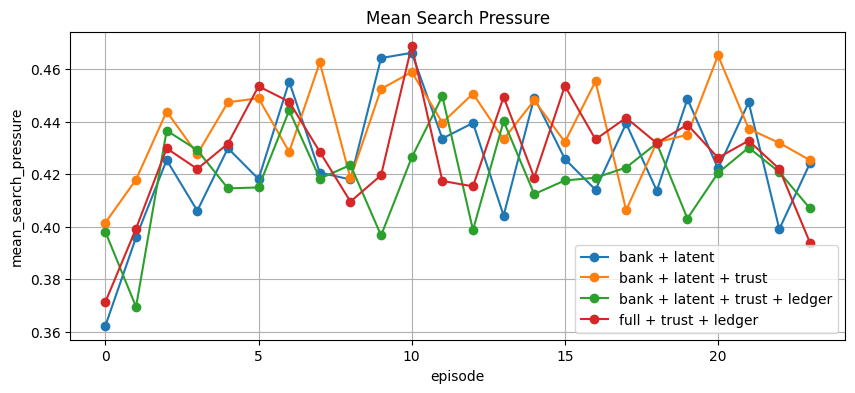

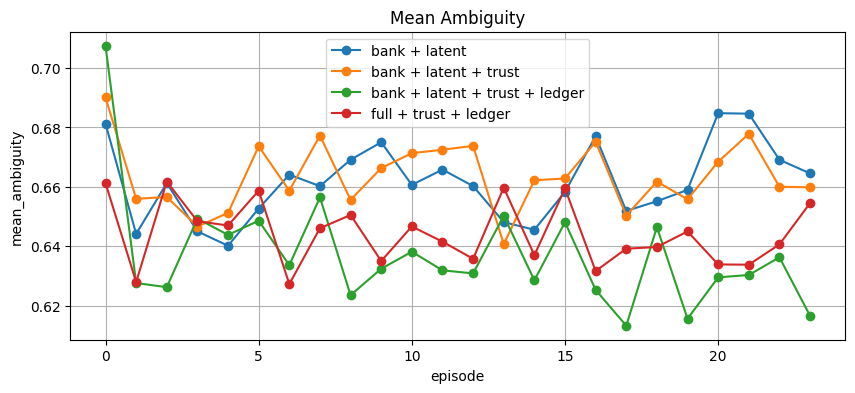

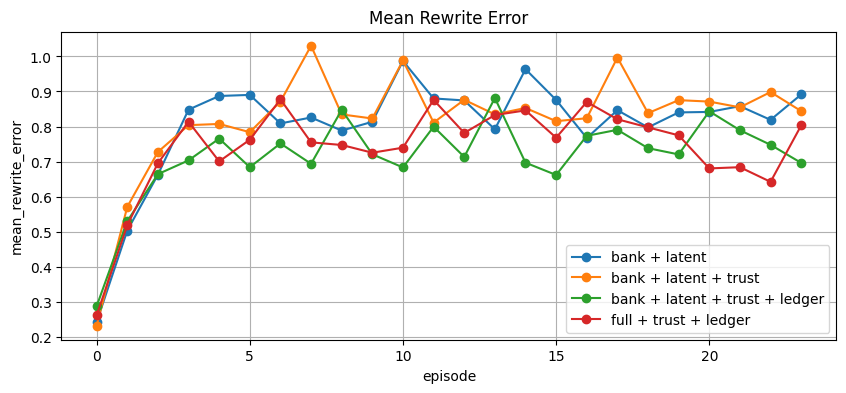

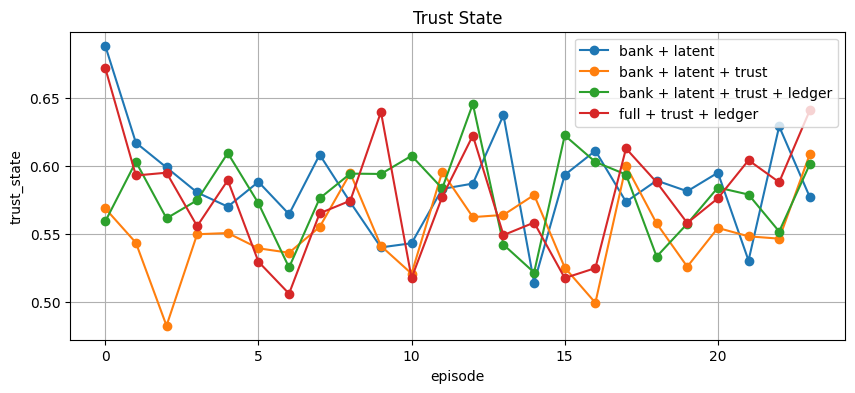

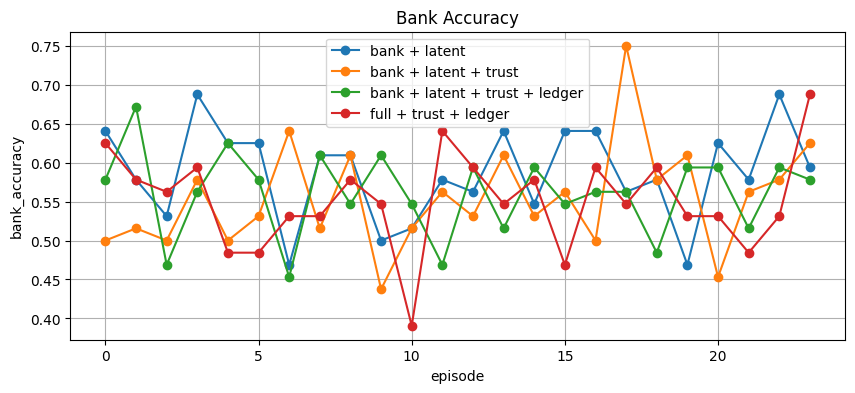

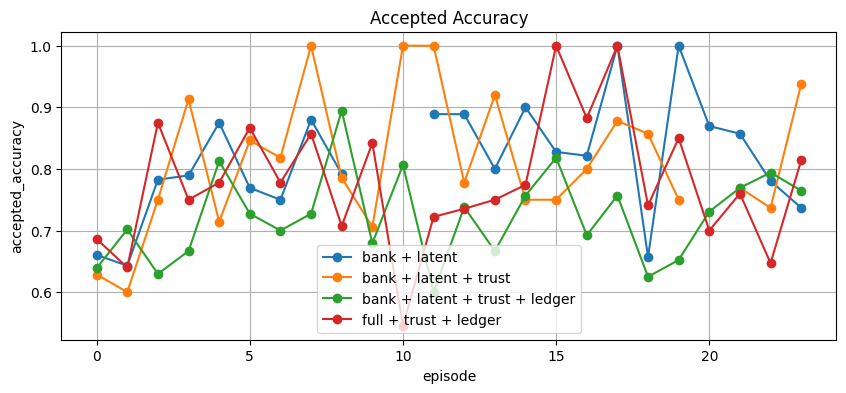

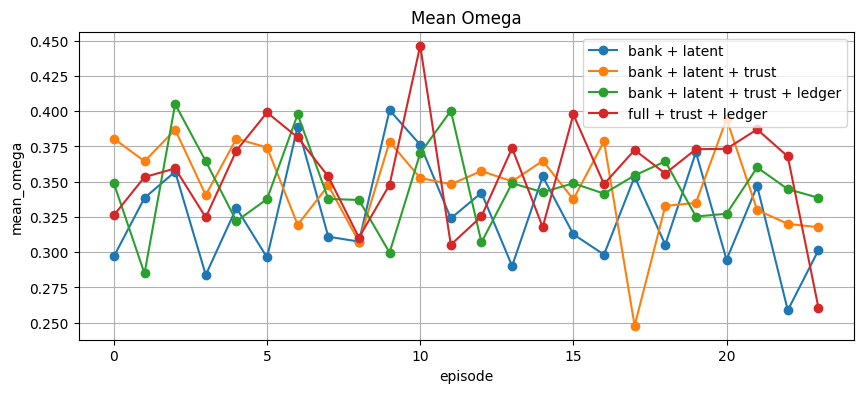

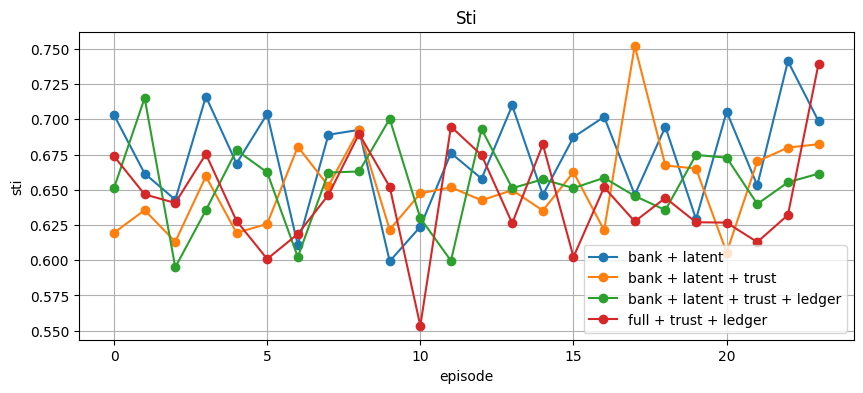

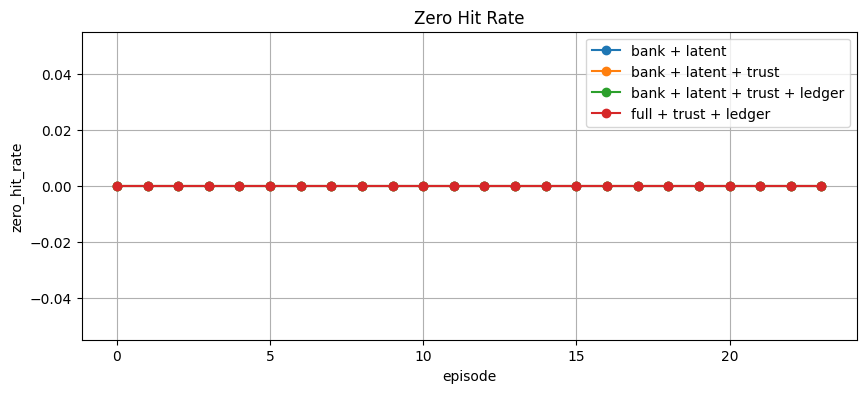

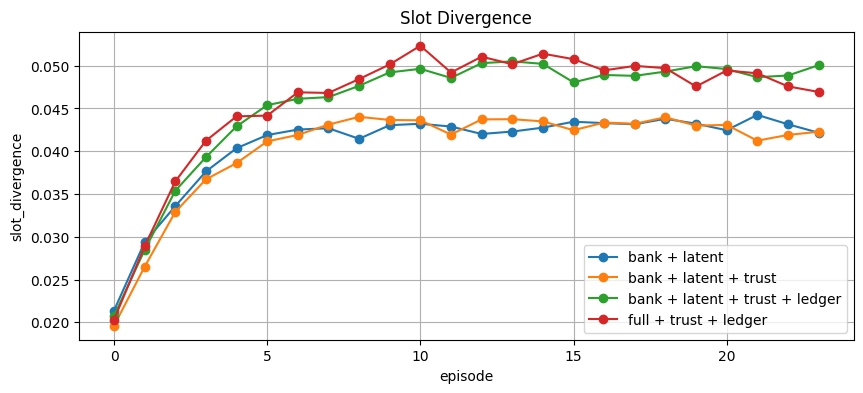

In [11]:

metrics = [
    "mean_search_pressure",
    "mean_ambiguity",
    "mean_rewrite_error",
    "trust_state",
    "bank_accuracy",
    "accepted_accuracy",
    "mean_omega",
    "sti",
    "zero_hit_rate",
    "slot_divergence",
]

for metric in metrics:
    plt.figure(figsize=(10, 4))
    for mode in modes:
        df = results[results["mode"] == mode]
        plt.plot(df["episode"], df[metric], marker="o", label=mode)
    plt.title(metric.replace("_", " ").title())
    plt.xlabel("episode")
    plt.ylabel(metric)
    plt.legend(loc="best")
    plt.show()



## Search-law summary

This ranks modes by reduction in search pressure first, then reports passive outcome changes.


In [12]:

summary_rows = []

for mode in modes:
    df = results[results["mode"] == mode].reset_index(drop=True)
    early = df.iloc[:6]
    late = df.iloc[-6:]

    summary_rows.append({
        "mode": mode,
        "early_pressure": float(early["mean_search_pressure"].mean()),
        "late_pressure": float(late["mean_search_pressure"].mean()),
        "pressure_drop": float(early["mean_search_pressure"].mean() - late["mean_search_pressure"].mean()),
        "early_ambiguity": float(early["mean_ambiguity"].mean()),
        "late_ambiguity": float(late["mean_ambiguity"].mean()),
        "ambiguity_drop": float(early["mean_ambiguity"].mean() - late["mean_ambiguity"].mean()),
        "early_rewrite_error": float(early["mean_rewrite_error"].mean()),
        "late_rewrite_error": float(late["mean_rewrite_error"].mean()),
        "rewrite_error_drop": float(early["mean_rewrite_error"].mean() - late["mean_rewrite_error"].mean()),
        "early_trust": float(early["trust_state"].mean()),
        "late_trust": float(late["trust_state"].mean()),
        "trust_gain": float(late["trust_state"].mean() - early["trust_state"].mean()),
        "passive_omega_gain": float(early["mean_omega"].mean() - late["mean_omega"].mean()),
        "passive_sti_gain": float(late["sti"].mean() - early["sti"].mean()),
        "passive_zero_hit_gain": float(late["zero_hit_rate"].mean() - early["zero_hit_rate"].mean()),
        "mean_bank_accuracy": float(df["bank_accuracy"].mean()),
        "mean_accepted_accuracy": float(df["accepted_accuracy"].mean()),
    })

search_df = pd.DataFrame(summary_rows).sort_values(
    ["pressure_drop", "ambiguity_drop", "rewrite_error_drop", "trust_gain"],
    ascending=False
)

search_df


,mode,early_pressure,late_pressure,pressure_drop,early_ambiguity,late_ambiguity,ambiguity_drop,early_rewrite_error,late_rewrite_error,rewrite_error_drop,early_trust,late_trust,trust_gain,passive_omega_gain,passive_sti_gain,passive_zero_hit_gain,mean_bank_accuracy,mean_accepted_accuracy
3,full + trust + ledger,0.417922,0.424269,-0.006347,0.650838,0.641243,0.009595,0.625659,0.730601,-0.104943,0.589218,0.592650,0.003432,0.002819,0.002819,0.0,0.551432,0.779222
1,bank + latent + trust,0.431205,0.437806,-0.006601,0.662365,0.663952,-0.001587,0.654506,0.863702,-0.209196,0.539205,0.557005,0.017801,0.032877,0.032877,0.0,0.554036,0.812538
2,bank + latent + trust + ledger,0.410475,0.418870,-0.008396,0.650501,0.629095,0.021406,0.606109,0.756134,-0.150024,0.580177,0.567915,-0.012262,0.000411,0.000411,0.0,0.560547,0.722883
0,bank + latent,0.406282,0.425843,-0.019561,0.654085,0.669536,-0.015451,0.672550,0.841421,-0.168871,0.607285,0.583798,-0.023487,0.004359,0.004359,0.0,0.587240,0.816781



## Read the result

This notebook does not ask:
- which mode forced zero best?

It asks:
- which mode reduced contradiction/ambiguity/rewrite spill most cleanly?
- and then, as a consequence, what happened to omega, STI, and zero-hit rate?

That is the corrected framing.
